If we increase the context to more chars then the size increases and the computations becomes expensive
For two chars it is 27 x 27 possibilities a,b (bigram) single character context.
For three chars ab, c one character context then there are 27 x 27 x 27 possibilities. For more character context there will be more dimensions and it would be very difficult.

The paper shown in the video uses a word level language model. They use each word in the vocabulary of 17000 words and created a 30 dimensional feature vector. 


In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
words = open("/Users/deepakkumar/Downloads/firstnames.txt", "r").read().splitlines()

In [3]:
words = list(filter(lambda x: len(x) > 0,map(lambda x: x.lower(), words)))

In [4]:
words[:10]

['abhishek',
 'aman',
 'harsh',
 'ayush',
 'aditi',
 'anjali',
 'shubham',
 'anushka',
 'rohit',
 'saurabh']

In [5]:
vocab = sorted(list(set("".join(words))) + ["."])

In [6]:
vocab

['.',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

In [7]:
stoi_m = { s:i for i,s in enumerate(vocab) }
itos_m = { i:s for i,s in enumerate(vocab)}

stoi = lambda s: stoi_m[s]
itos = lambda i: itos_m[i]

In [8]:
# build the dataset

block_size = 3 # context length, how many characters we take to predict the next one ?
X, Y = [], []

for w in words:
    print(w)
    context = [0] * block_size
    for ch in w + ".":
        ix = stoi(ch)
        X.append(context)
        Y.append(ix)
        print("".join([itos(c) for c in context]), " -> ", itos(ix))
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

abhishek
...  ->  a
..a  ->  b
.ab  ->  h
abh  ->  i
bhi  ->  s
his  ->  h
ish  ->  e
she  ->  k
hek  ->  .
aman
...  ->  a
..a  ->  m
.am  ->  a
ama  ->  n
man  ->  .
harsh
...  ->  h
..h  ->  a
.ha  ->  r
har  ->  s
ars  ->  h
rsh  ->  .
ayush
...  ->  a
..a  ->  y
.ay  ->  u
ayu  ->  s
yus  ->  h
ush  ->  .
aditi
...  ->  a
..a  ->  d
.ad  ->  i
adi  ->  t
dit  ->  i
iti  ->  .
anjali
...  ->  a
..a  ->  n
.an  ->  j
anj  ->  a
nja  ->  l
jal  ->  i
ali  ->  .
shubham
...  ->  s
..s  ->  h
.sh  ->  u
shu  ->  b
hub  ->  h
ubh  ->  a
bha  ->  m
ham  ->  .
anushka
...  ->  a
..a  ->  n
.an  ->  u
anu  ->  s
nus  ->  h
ush  ->  k
shk  ->  a
hka  ->  .
rohit
...  ->  r
..r  ->  o
.ro  ->  h
roh  ->  i
ohi  ->  t
hit  ->  .
saurabh
...  ->  s
..s  ->  a
.sa  ->  u
sau  ->  r
aur  ->  a
ura  ->  b
rab  ->  h
abh  ->  .
muskan
...  ->  m
..m  ->  u
.mu  ->  s
mus  ->  k
usk  ->  a
ska  ->  n
kan  ->  .
rahul
...  ->  r
..r  ->  a
.ra  ->  h
rah  ->  u
ahu  ->  l
hul  ->  .
utkarsh
...  -> 

In [9]:
# we have created 32 examples and 32 corresponding labels

In [158]:
# lookup table
C = torch.randn((27, 3))
# each 2x2 in C reprecents a features vector of size 2

C[[0, 0, 0, 1, 0]]

In [159]:
C.shape

torch.Size([27, 3])

In [12]:
X[0]

tensor([0, 0, 0])

In [160]:
emb = C[X]

In [136]:
emb[0]

tensor([[ 0.4025, -0.2021,  0.1650],
        [ 0.4025, -0.2021,  0.1650],
        [ 0.4025, -0.2021,  0.1650]])

emb @ weights + bias
instead of concatenating we can use more efficient view method
under the hood a tensor is always one dimensional, tensor.storage
Read more on pytorch internals here http://blog.ezyang.com/2019/05/pytorch-internals/

In [134]:
emb[0]

tensor([[ 1.1554, -1.2418],
        [ 1.1554, -1.2418],
        [ 1.1554, -1.2418]])

In [131]:
w1 = torch.randn((9, 100))

In [132]:
b1 = torch.randn(100)

In [18]:
b1

tensor([-1.5502, -0.4603,  1.1818, -1.1397, -1.1131,  1.8149,  0.8269,  0.2718,
         0.4974, -0.4271, -1.2859,  0.0239, -0.9767,  1.5267, -1.4904, -0.4037,
         0.6611, -0.2313, -0.3813,  0.9448,  0.5524, -1.6326,  1.6574, -1.5635,
         1.2368, -0.9670,  0.7211,  1.1287, -0.4324,  0.6364, -0.0157,  2.1227,
         0.3183, -0.2440, -0.3714,  1.1720,  0.5522, -0.1147, -1.0941,  0.6131,
        -2.0393, -0.0601,  0.8935, -2.0182, -2.0230,  0.1804, -1.1042,  0.4854,
         1.4253,  1.1671,  1.2050,  1.2855,  0.6162, -1.8562,  1.3134,  0.3702,
         0.2434, -1.6304,  0.6391,  0.2187, -1.6853,  1.6905, -0.8828,  0.3256,
        -0.8947, -1.2105, -1.1872, -0.7895, -0.6880,  0.1615,  0.9705, -0.3407,
        -0.3135,  0.6062,  0.1531,  0.7970,  1.9469, -0.6628, -0.5133, -1.7145,
        -0.8742,  1.0640,  0.3142, -0.2321,  0.4347,  0.9273, -0.0162, -0.8178,
         0.0947, -0.1641, -0.1911,  0.2249,  1.0904, -1.0281, -0.3466,  0.9887,
         0.9382, -0.3080, -0.0940, -0.13

In [137]:
h = torch.tanh(emb.view(-1, 9) @ w1 + b1)

In [20]:
# output contains 27 outputs

In [138]:
w2 = torch.randn((100, 27))

In [139]:
b2 = torch.randn(27)

In [140]:
logits = h @ w2 + b2

In [141]:
counts = logits.exp()
probs = (counts / counts.sum(1, keepdim=True))
loss = -probs[torch.arange(8752), Y].log().mean()
# OR
# loss = F.cross_entropy(logits, Y)

In [142]:
loss

tensor(18.8132)

In [147]:
# summary of the above section
g = torch.Generator().manual_seed(202020)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((9, 100), generator=g)
B1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
B2 = torch.randn(27, generator=g)
parameters = [C, W1, B1, W2, B2]

In [146]:
# number of parameters in the network
sum(param.nelement() for param in parameters)

3781

In [148]:
for p in parameters:
    p.requires_grad = True
loss = 100

In [149]:
# create a variable learning rate
lre = torch.linspace(-3, 0, 1000) # using exponent of 10 with 1000 steps
lrs = 10**lre

In [156]:
C.shape

torch.Size([27, 2])

In [173]:
# Training network
lossY = []

for i in range(1000):
    # minibatch construct
    ix = torch.randint(0, X.shape[0], (32,))
    # forward pass
    embeddings = C[X[ix]] # (32, 3, 2)
    H = torch.tanh(embeddings.view(-1, 9) @ W1 + B1)
    logits = H @ W2 + B2
    # always use cross-entropy in production, this has many corrections and optimizations
    loss = F.cross_entropy(logits, Y[ix])
    # backward pass
    for p in parameters[1:]: # reset the gradients
        p.grad = None
    loss.backward()
    # update weights
    # learning_rate = lrs[i]
    learning_rate = 0.0674 / 10
    for p in parameters[1:]:
        p.data += -learning_rate * p.grad

    print("Current loss", loss.item())

    lossY.append(loss.item())

Current loss 2.01446795463562
Current loss 2.5060319900512695
Current loss 1.995400071144104
Current loss 2.4119372367858887
Current loss 1.8738410472869873
Current loss 1.9303133487701416
Current loss 1.7609307765960693
Current loss 2.0352280139923096
Current loss 2.5093839168548584
Current loss 1.8938744068145752
Current loss 1.9464755058288574
Current loss 2.0574276447296143
Current loss 2.4071755409240723
Current loss 2.116701126098633
Current loss 2.031588315963745
Current loss 2.340625286102295
Current loss 1.9165996313095093
Current loss 1.7490348815917969
Current loss 1.9616812467575073
Current loss 1.8861563205718994
Current loss 1.9000871181488037
Current loss 1.8900874853134155
Current loss 1.7078276872634888
Current loss 1.8554954528808594
Current loss 1.6866052150726318
Current loss 2.120758056640625
Current loss 2.1179356575012207
Current loss 1.866033673286438
Current loss 1.656272530555725
Current loss 1.979500412940979
Current loss 1.970313310623169
Current loss 2.1791

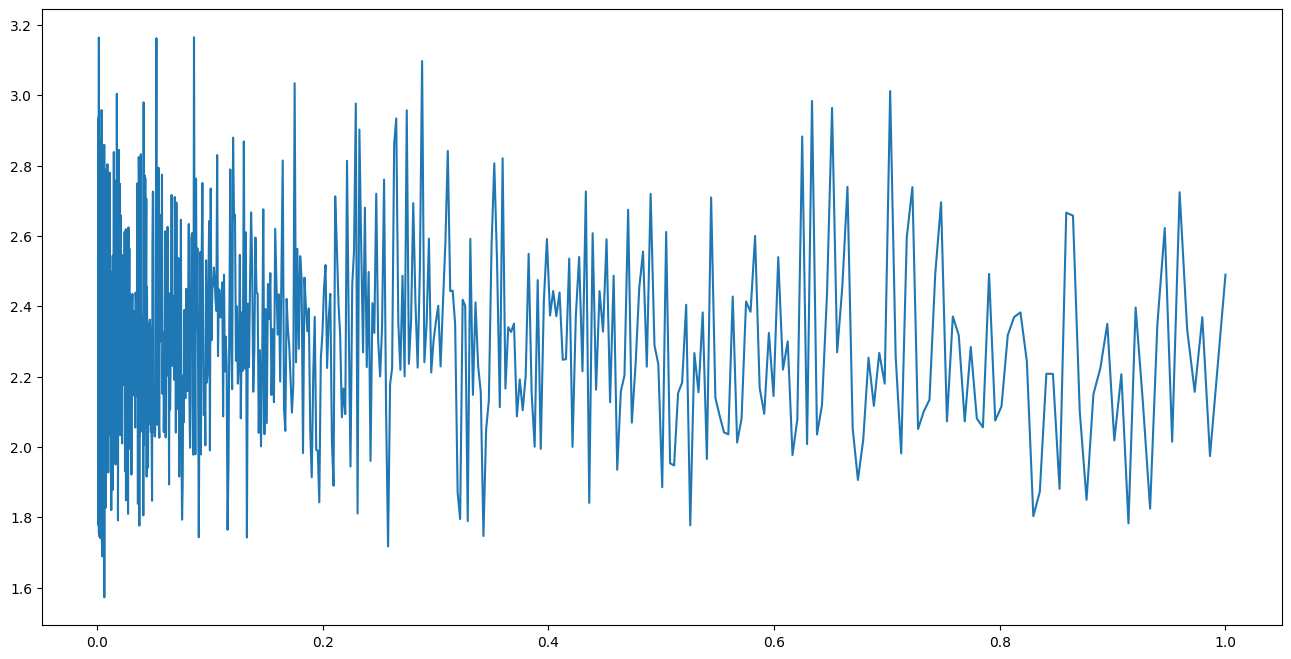

In [104]:
plt.figure(figsize=(16,8))
plt.plot(lrs, lossY)

In [103]:
m = min(lossY)
i = lossY.index(m)
# best learning rate is
print("Loss is ", m)
print("Learning rate ", lrs[i].item())


Loss is  1.5723602771759033
Learning rate  0.006424035411328077


The best learning rate that we were able to create is 0.0624878816306591 with loss 1.807352066040039)

With loss reaching zero the neural network starts to memorize all the training data. Basically this will simply predict the training set as output. Therefore it is better to have a non zero value to have a better model.

Therefore we need to split the training data set we need to use a training, dev/validation, test set.

Training set can be of 80%, and validation can be of 20% and test dataset can be 10%

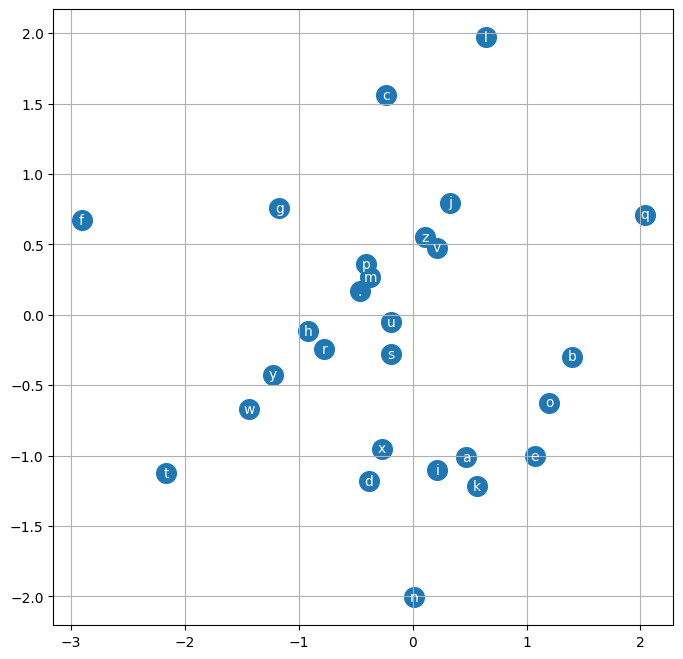

In [174]:
# Visualization of data

plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos(i), ha="center", va="center", color="white")
plt.grid('minor')

In [175]:
# sampling from network  with parameters = [C, W1, B1, W2, B2]
def sample(count: int):
    for i in range(count):
        ix = 0
        gen_chars = []
        context = [0] * block_size
        while True:
            emb = C[torch.tensor([context])]
            h = torch.tanh(emb.view(1, -1) @ W1 + B1)
            logits = h @ W2 + B2
            probs = F.softmax(logits, dim = 1)
            ix = torch.multinomial(probs, num_samples=1).item() # sampling from the probs
            context = context[1:] + [ix]
            gen_chars.append(ix)
            if ix == 0:
                break
        print("".join(itos(i) for i in gen_chars))


In [181]:
sample(10)

itul.
nok.
vipa.
amtosh.
shiomansha.
rinul.
gash.
shanapal.
kausureri.
marth.
